#Practical Simulation – Day 1
We are analysing genomic data from two populations of Anopheles gambiae from two different locations. We have 41 diploid samples from GN and 99 diploid samples for BF. We wish to compare and isolation only with an Isolation-with-Migration (IM) model and estimate their demographic history.

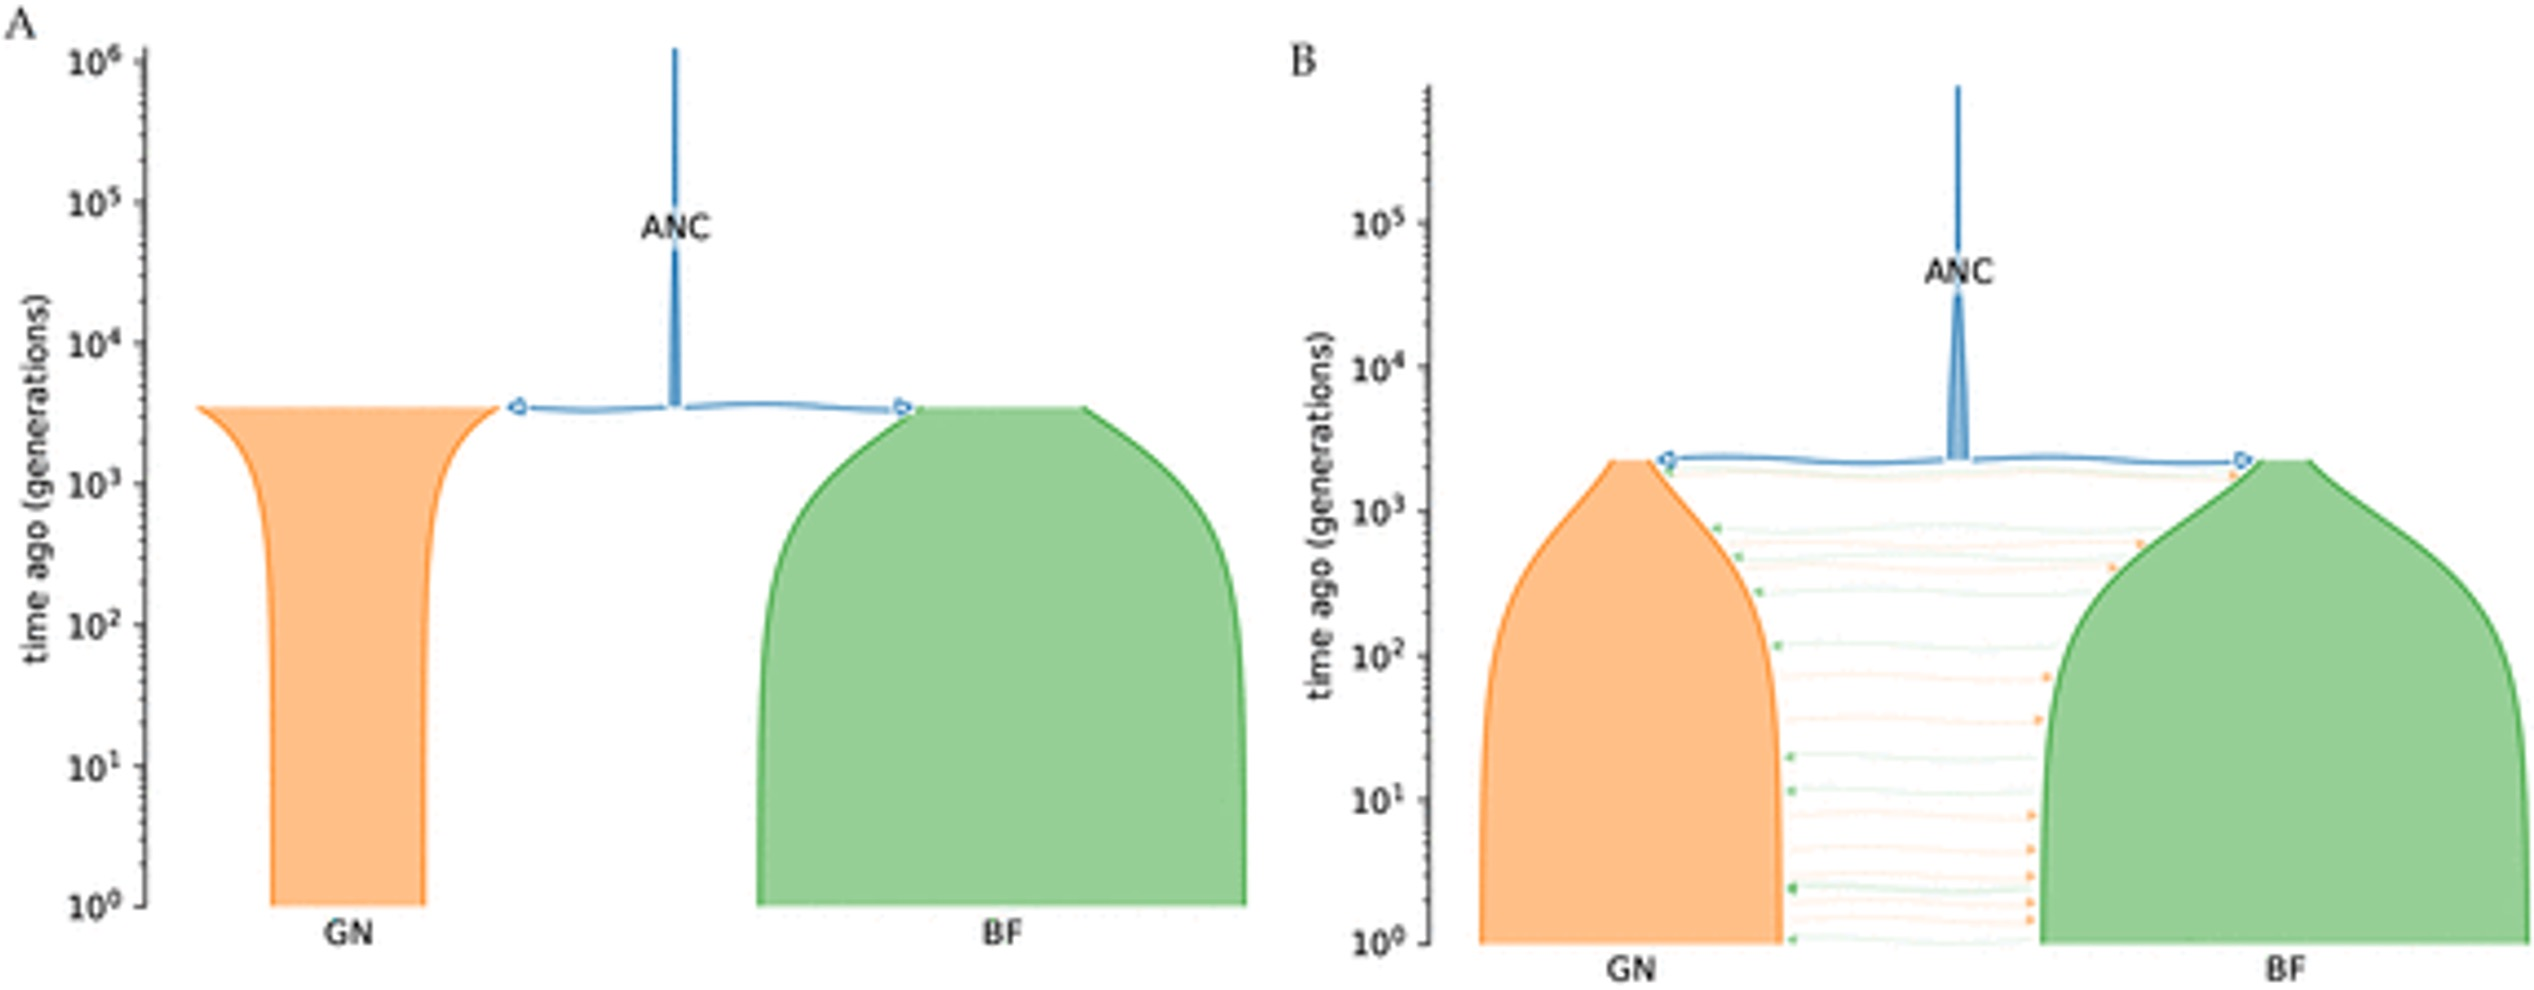

### Task 1: based on the following information, decide on suitable prior probabilities and perform
random samples from them. You need to make sure that you are covering the whole range of all
prior distributions.
Assume a mutation rate of 3.5e-9, a recombination rate of 1.45e-8, and a sequence length of 150,000 bp.
> T_split: we know that these populations have been separated by at least 2,000 generations and a major environmental change between these two locations happened around 3,000 generations ago.

> N1/N2: we know from capture-recapture data that population 1 is approximately 2 times smaller than population 2; we also don't have a clear intuition of each value but from previous findings we expect values for population 1 to be between 500,000 and 1,500,000.

> mig: we expect either complete isolation after the split (rate=0) or pervasive migration (rate=0.1).

> Nanc: we know this value with high confidence to be around 500,000.

I suggest to start choosing one value for parameter and run simulations under this model. Once this works well, then try to impose some distributions on each parameter as indicated and perform several simulations, say 1,000 (it takes long n Anopheles, as population sizes are very high), by jointly randomly sampling from each distribution.

You can look for additional instructions from the documentation of msprime to implement your models:
additional demographic models: https://tskit.dev/msprime/docs/stable/demography.html


other examples: https://tskit.dev/tutorials/popgen.html
You also need to implement how to draw random samples from a probability distribution using numpy package in python. For instance, draws from finite array can be done as
https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html or from a uniform distribution as
https://numpy.org/doc/stable/reference/random/generated/numpy.random.uniform.html or from a Normal distribution as
https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

### Task 2: Assume that the observed summary stats are in `mosquito-observed.csv`
>Fst,dxy,segsites1,segsites2,pi1,pi2,tajima1,tajima2
-0.0001438265675,0.002740131461,0.03447079265,0.05331101312,0.002742748696,0.002737883882,-2.050512061,-2.18978437

Estimate the parameters of the best model using ABC. As first trial, assume that we know all
parameters but T_split. In particular, assume that there is no migration and N1=750,000 and
N2=1,500,000. Produce the posterior distribution of T_split.
You can look at this link to calculate summary statistics using msprime
https://tskit.dev/tskit/docs/stable/stats.html#sec-stats

###Task 3 (optional, advanced): Attempt to jointly infer T_split, N1 and N2.

In [68]:
# 1. Install everything silently
!pip install -q msprime tskit demes demesdraw

# 2. Force a path refresh
import site
from importlib import reload
reload(site)

<module 'site' (frozen)>

In [69]:
# Task: decide on prior distributions and generate simulations
import os
import csv
import msprime
import demesdraw
import matplotlib.pyplot as plt
import tskit
import numpy as np
import pandas as pd

In [70]:
# Function for simulating data under an isolation model with parameters:
# Nanc, T_split, N1, N2

def no_mig(params, sample_sizes, seed, reco):
# Initialize the demography object
    demog = msprime.Demography()

    # 1. Define the populations (Current)
    demog.add_population(name="GN", initial_size=params["N1"])
    demog.add_population(name="BF", initial_size=params["N2"])

    # 2. Define the ancestral population
    demog.add_population(name="Anc", initial_size=params["N_anc"])

    # 3. Define the split (Backward: merge GN and BF into Anc)
    # This replaces MassMigration. It handles the 'proportion=1.0' automatically.
    demog.add_population_split(time=params["T_split"], derived=["GN", "BF"], ancestral="Anc")

    # 4. Simulate Ancestry
    # Note: sample_sizes should be 112 for GN and 112 for BF (total 224 haplotypes)
    ts = msprime.sim_ancestry(
        samples={"GN": sample_sizes[0], "BF": sample_sizes[1]},
        demography=demog,
        sequence_length=params["length"],
        recombination_rate=params["reco"],
        random_seed=params.get("seed")
    )

    # 5. Add Mutations
    mts = msprime.sim_mutations(ts, rate=params["mut"])

    return demog, mts


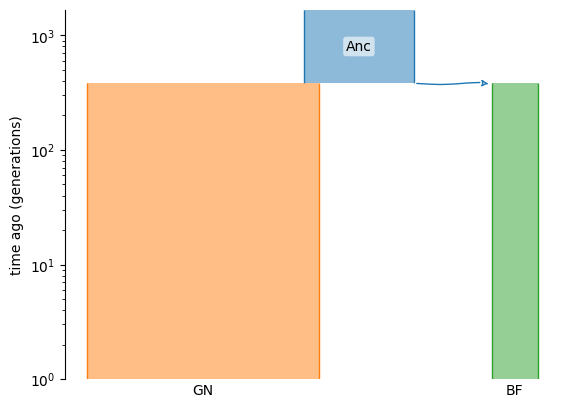

In [71]:
demog, ts = no_mig(params, sample_sizes, seed, params["reco"])

# Plot a schematic of the model
demesdraw.tubes(demog.to_demes(), ax=plt.gca(), seed=1, log_time=True)
plt.show()

In [72]:
# Function for simulating data under an isolation with migration model with parameters:
# Nanc, T_split, N1, N2, mig

def im(params, sample_sizes, seed, reco):
# Initialize the demography object
    demog = msprime.Demography()

    # 1. Define the populations
    demog.add_population(name="GN", initial_size=params["N1"])
    demog.add_population(name="BF", initial_size=params["N2"])
    demog.add_population(name="Anc", initial_size=params["N_anc"])

# 2. Add Continuous Migration
    # Note: 'rate' is the fraction of the population replaced by migrants each generation.
    # Backward-in-time: source="BF", dest="GN" means BF individuals move to GN.
    # This represents FORWARD gene flow from GN into BF.
    mig_rate = params.get("mig", 0.1)

    if mig_rate != 0:
        # Forward GN -> BF (Backward BF -> GN)
        demog.set_migration_rate(source="BF", dest="GN", rate=abs(mig_rate))
        # Forward BF -> GN (Backward GN -> BF)
        demog.set_migration_rate(source="GN", dest="BF", rate=abs(mig_rate))

    # 3. Define the split (Backward: merge GN and BF into Anc)
    # This replaces MassMigration. It handles the 'proportion=1.0' automatically.
    demog.add_population_split(time=params["T_split"], derived=["GN", "BF"], ancestral="Anc")

    # 4. Simulate Ancestry
    # Note: sample_sizes should be 112 for GN and 112 for BF (total 224 haplotypes)
    ts = msprime.sim_ancestry(
        samples={"GN": sample_sizes[0], "BF": sample_sizes[1]},
        demography=demog,
        sequence_length=params["length"],
        recombination_rate=params["reco"],
        random_seed=params.get("seed")
    )

    # 5. Add Mutations
    mts = msprime.sim_mutations(ts, rate=params["mut"])

    return demog, mts

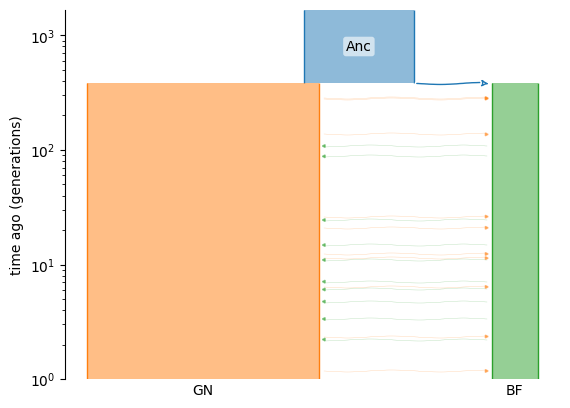

In [73]:
demog, ts = im(params, sample_sizes, seed, params["reco"])

# Plot a schematic of the model
demesdraw.tubes(demog.to_demes(), ax=plt.gca(), seed=1, log_time=True)
plt.show()

In [74]:
# Define some initial parameters (fixed defaults)
k = 10 #scaling parameter to make simulations faster
params = {
    "N1": 750_000 / k,    # Population 1 (GN) size
    "N2": 1_500_000 / k,     # Population 2 (BF) size
    "T_split": 3_000 / k,    # Time of population split
    "N_anc": 500_000 / k,   # Ancestral population size (500,000)
    "mut": 3.5e-9 * k,      # Mutation rate, fixed
    "length": 150_000,      # Sequence length, fixed. THis is the size of windows we use in the genome.
    "reco": 1.45e-8 * k,     # recombination rate, fixed
    "mig": 0.1            # migration rate, fixed
}

In [75]:
# Define additional parameters
sample_sizes = [41*2, 99*2]  # Sample sizes for two populations (41 in GN and 99 in BF)
seed = None               # Random seed

## Task 1: define priors

In [76]:
# Output directory
output_directory = "."
# Output file name
output_file = os.path.join(output_directory, "mosquito-task1.csv")

In [77]:
# Open the output file in write mode
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile, delimiter=",")

    # Write header
    writer.writerow(["Sim", "N1", "N2", "T_split", "mig"])

    # Perform sampling
    for i in range(100):

        params["N1"] = np.random.randint(low=500_000 / k, high=1_500_000 /k, size=1)[0]
        params["N2"] = int(params["N1"] * 2 / k)
        params["mig"] = np.random.uniform(low=0, high=0.1, size=1)[0]
        params["T_split"] = np.random.randint(low=2_000 / k, high=4_000 / k, size=1)[0]

        # Write data to file
        writer.writerow([i+1, params["N1"], params["N2"], params["T_split"], params["mig"]])


## Task 2: simulate data for ABC

In [78]:
# Output directory
output_directory = "."
# Output file name
output_file = os.path.join(output_directory, "mosquito-task2_no_mig.csv")

In [79]:
# Open the output file in write mode
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile, delimiter=",")

    # Write header
    writer.writerow(["N1", "N2", "T_split", "mig", "Fst", "dxy", "segsites1", "segsites2", "pi1", "pi2", "tajima1", "tajima2"])

    # Perform simulations
    for i in range(10): # We are performing only 10 simulations as they take very long to complete.

        params["N1"] = 750_000 / k
        params["N2"] = 1_500_000 / k
        params["mig"] = 0
        params["T_split"] = np.random.randint(low=2_000 / k, high=4_000 / k, size=1)[0]

        demog, ts = no_mig(params, sample_sizes, seed, params["reco"])

        dxy = ts.divergence(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        Fst = ts.Fst(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        ssites = ts.segregating_sites(sample_sets=[ts.samples(population=0), ts.samples(population=1)])
        div = ts.diversity(sample_sets=[ts.samples(population=0), ts.samples(population=1)])
        tajima = ts.Tajimas_D(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        # Write data to file or print data
        writer.writerow([params["N1"], params["N2"], params["T_split"], params["mig"], Fst, dxy, ssites[0], ssites[1], div[0], div[1], tajima[0], tajima[1]])


In [80]:
# Output directory
output_directory = "."
# Output file name
output_file = os.path.join(output_directory, "mosquito-task2_im.csv")

In [81]:
# Open the output file in write mode
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile, delimiter=",")

    # Write header
    writer.writerow(["N1", "N2", "T_split", "mig", "Fst", "dxy", "segsites1", "segsites2", "pi1", "pi2", "tajima1", "tajima2"])

    # Perform simulations
    for i in range(10): # We are performing only 10 simulations as they take very long to complete.

        params["N1"] = 750_000 / k
        params["N2"] = 1_500_000 / k
        params["mig"] = 0.1
        params["T_split"] = np.random.randint(low=2_000 / k, high=4_000 / k, size=1)[0]

        demog, ts = im(params, sample_sizes, seed, params["reco"])

        dxy = ts.divergence(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        Fst = ts.Fst(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        ssites = ts.segregating_sites(sample_sets=[ts.samples(population=0), ts.samples(population=1)])
        div = ts.diversity(sample_sets=[ts.samples(population=0), ts.samples(population=1)])
        tajima = ts.Tajimas_D(sample_sets=[ts.samples(population=0), ts.samples(population=1)])

        # Write data to file or print data
        writer.writerow([params["N1"], params["N2"], params["T_split"], params["mig"], Fst, dxy, ssites[0], ssites[1], div[0], div[1], tajima[0], tajima[1]])
